In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('wine_quality_merged.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [3]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


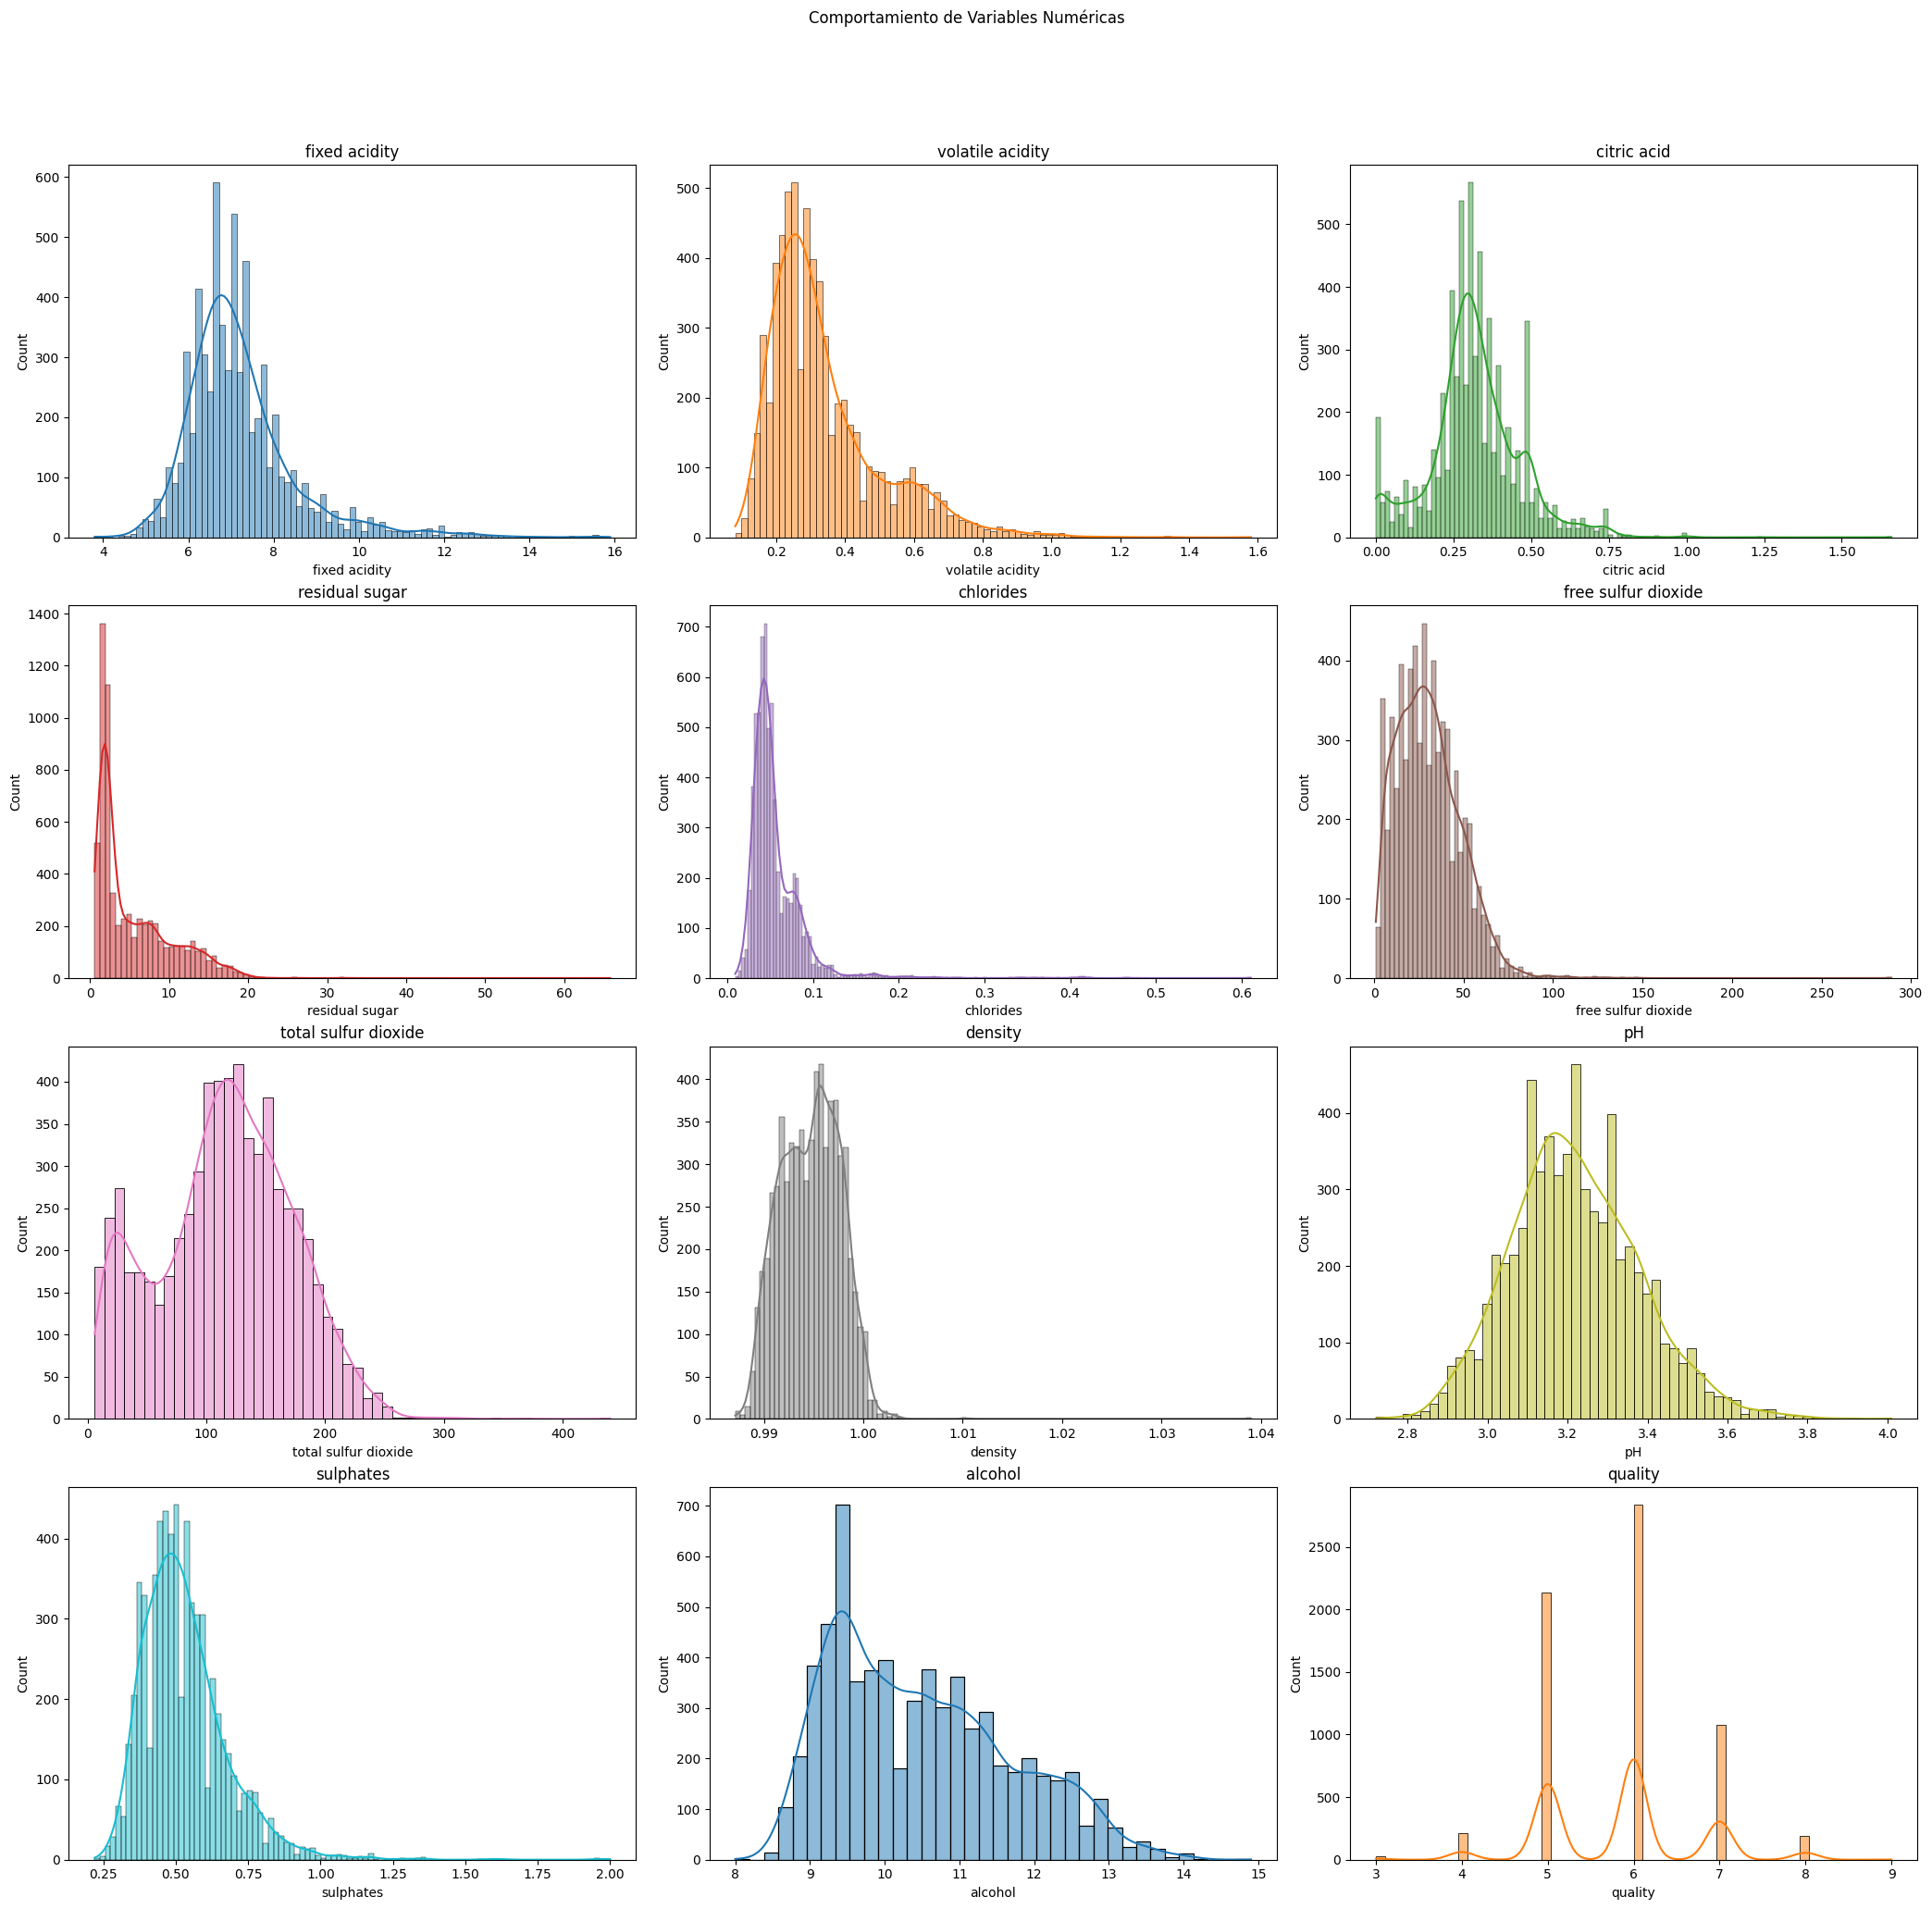

In [4]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

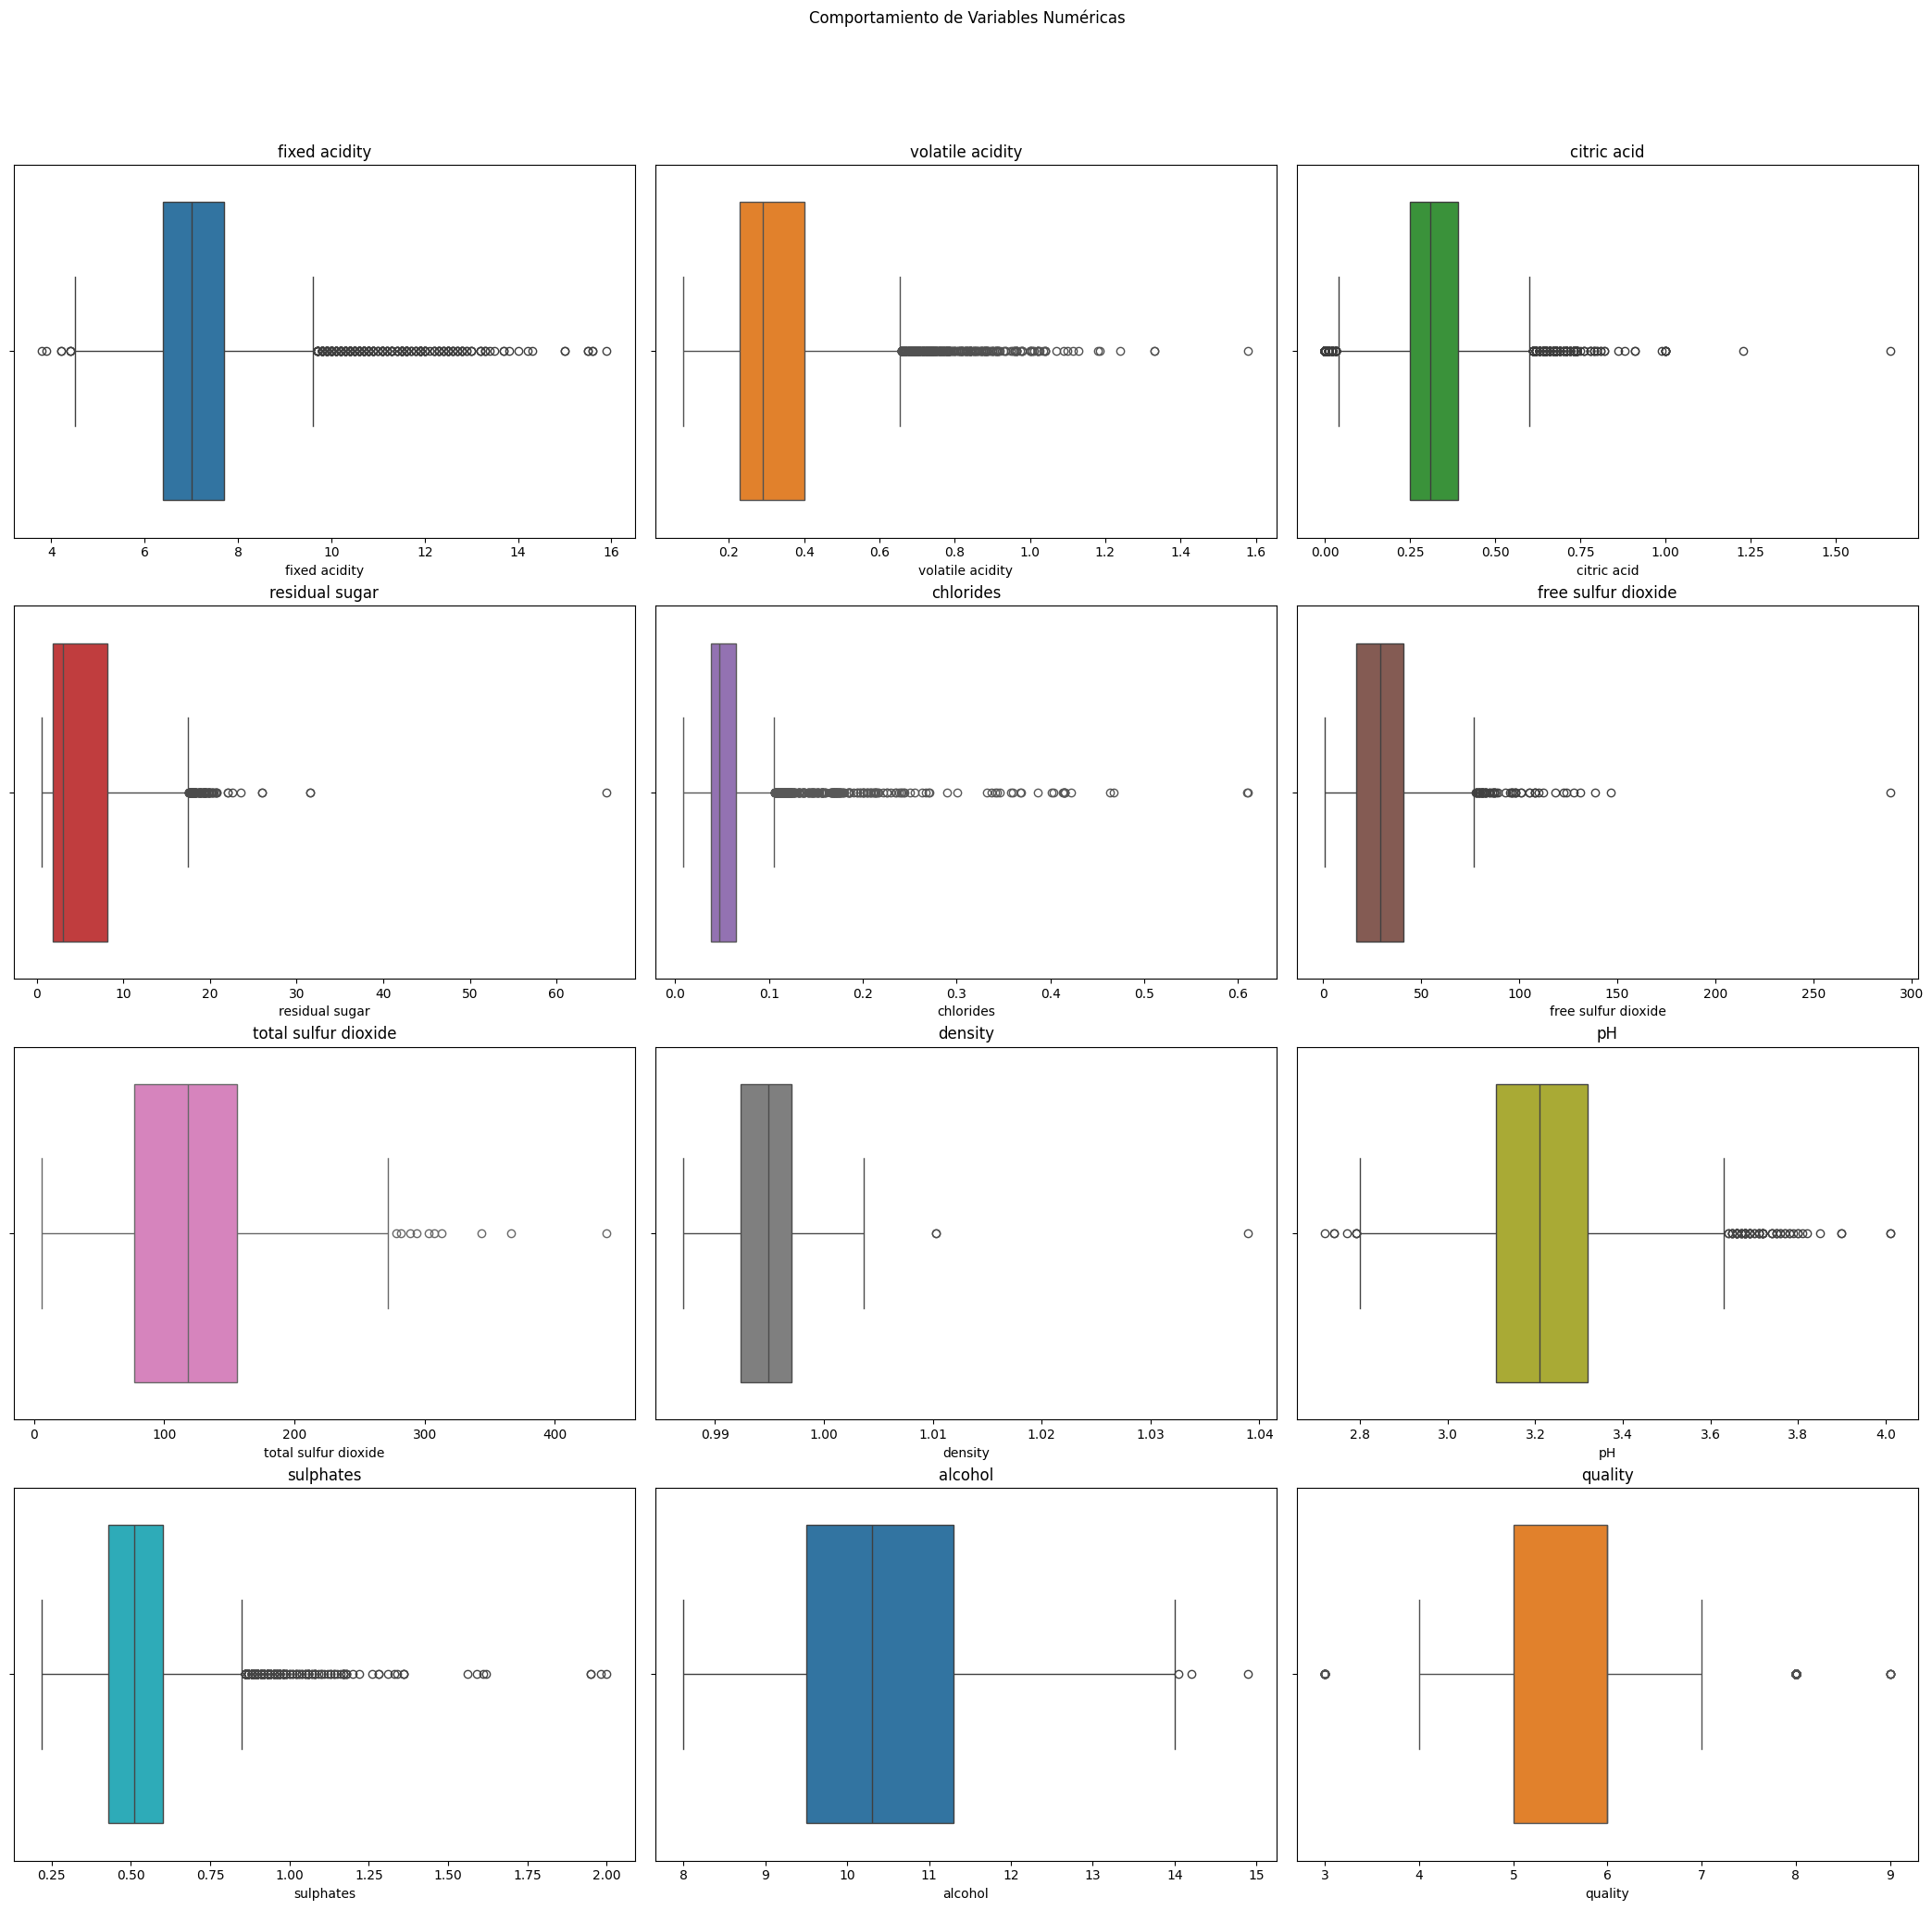

In [5]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.boxplot(data = data, x = col,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

- 2 valores de acido citrico sobrepasan el nivel legal de 1g/L
- 1 valor de azucar residual es el unico vino extremadamente dulce, el resto cae en medio-dulce,         medio-seco, y seco
- Valores mayores que 80 ppm en el dioxido de sulfuro libre se consideran atipicos antinaturales, el vino preservado con mas se deja para barriles vacios, no vino terminado
- 2 valores de dioxido de sulfuro total se pasan del limite legal general de 350 
- valores cercanos a 2 g/L en sulfatos agregados


No decidimos eliminar ningun valor de contenido de alcohol dado:
Normal alcohol content in wine generally ranges between 11% and 14% alcohol by volume (ABV), with 12–13% being the most common for table wine. Red wines typically sit higher at 13.5–15%+ ABV, while white and rosé wines are often lower, ranging from 10% to 13.5% ABV.

In [6]:
data_mod = data.copy()
data_mod.loc[data_mod['citric acid'] > 1, 'citric acid'] = np.nan
data_mod.loc[data_mod['residual sugar'] > 60, 'residual sugar'] = np.nan
data_mod.loc[data_mod['free sulfur dioxide'] > 80, 'free sulfur dioxide'] = np.nan
data_mod.loc[data_mod['total sulfur dioxide'] > 350, 'total sulfur dioxide'] = np.nan
data_mod.loc[data_mod['sulphates'] > 1.75, 'sulphates'] = np.nan
data_mod = data_mod.dropna()
data_mod.info()

<class 'pandas.DataFrame'>
Index: 6439 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6439 non-null   float64
 1   volatile acidity      6439 non-null   float64
 2   citric acid           6439 non-null   float64
 3   residual sugar        6439 non-null   float64
 4   chlorides             6439 non-null   float64
 5   free sulfur dioxide   6439 non-null   float64
 6   total sulfur dioxide  6439 non-null   float64
 7   density               6439 non-null   float64
 8   pH                    6439 non-null   float64
 9   sulphates             6439 non-null   float64
 10  alcohol               6439 non-null   float64
 11  quality               6439 non-null   int64  
 12  type                  6439 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 704.3 KB


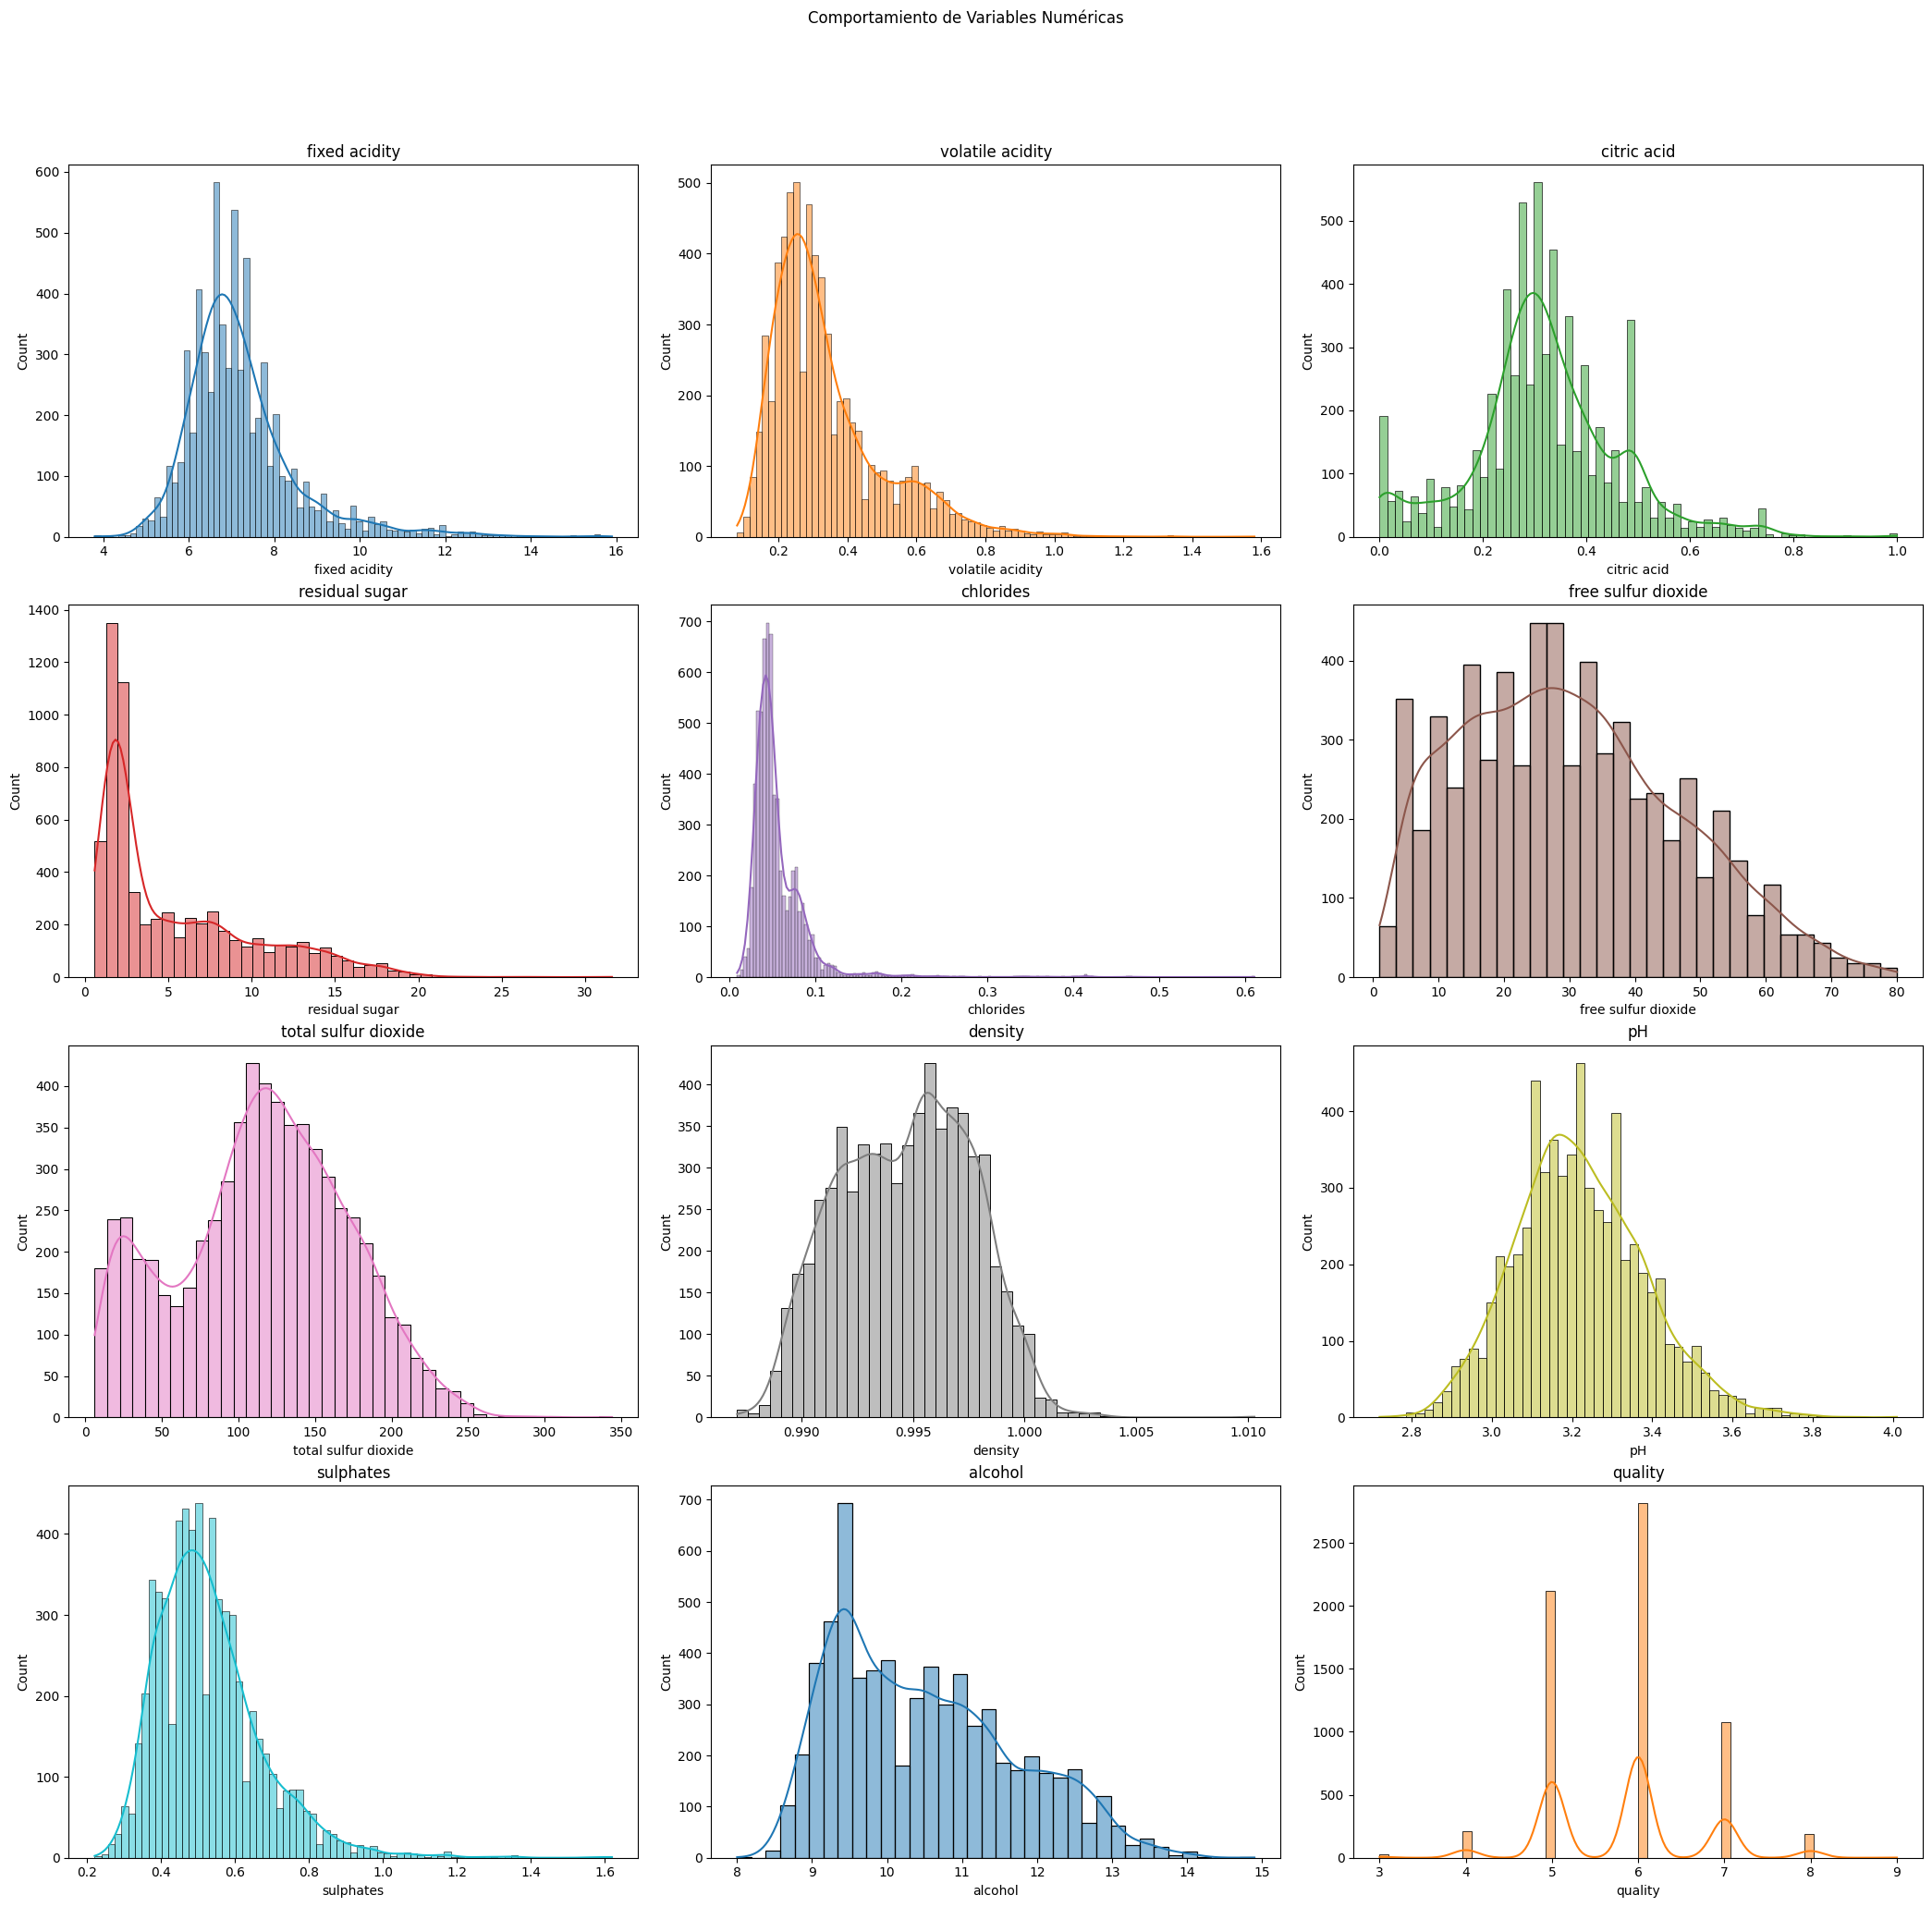

In [7]:
#Gráficos de Histogramas de frecuencia luego de la eliminación de atípicos
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data_mod.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data_mod, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

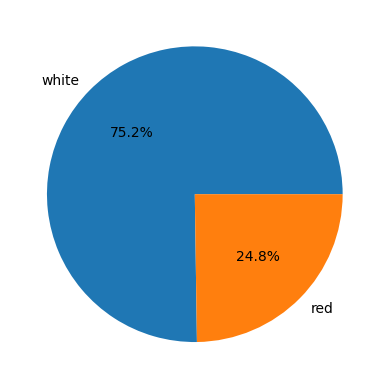

In [8]:
#Gáfico de Torta para la variable objetivo
plt.pie(x = data_mod['type'].value_counts(), labels = data_mod['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [9]:
#BALANCEO
data_red = data_mod[data_mod['type'] == 'red']
data_white = data_mod[data_mod['type'] == 'white']
print(f'El tamaño de la clase red es: {data_red.shape}\n El tamaño de la clase white es: {data_white.shape}')

El tamaño de la clase red es: (1595, 13)
 El tamaño de la clase white es: (4844, 13)


In [10]:
data_red_re = data_red.sample(data_white.shape[0], replace=True)
data_balanced = pd.concat([data_white, data_red_re])
data_balanced.reset_index(drop = True, inplace=True)
data_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 9688 entries, 0 to 9687
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         9688 non-null   float64
 1   volatile acidity      9688 non-null   float64
 2   citric acid           9688 non-null   float64
 3   residual sugar        9688 non-null   float64
 4   chlorides             9688 non-null   float64
 5   free sulfur dioxide   9688 non-null   float64
 6   total sulfur dioxide  9688 non-null   float64
 7   density               9688 non-null   float64
 8   pH                    9688 non-null   float64
 9   sulphates             9688 non-null   float64
 10  alcohol               9688 non-null   float64
 11  quality               9688 non-null   int64  
 12  type                  9688 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 984.1 KB


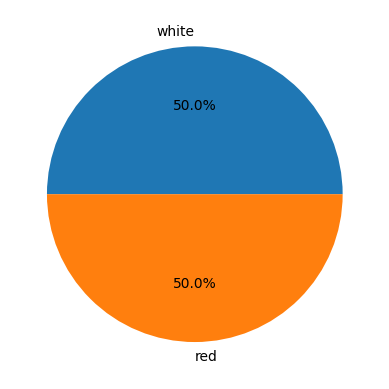

In [11]:
plt.pie(x = data_balanced['type'].value_counts(), labels = data_balanced['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [12]:
data_X = data_balanced.drop(columns='type')
data_y = data_balanced[['type']]

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = data_X.select_dtypes(include= ['int64','float64']).columns.to_list()
num_transformer1 = Pipeline(steps=[('scaler', MinMaxScaler())])
preprocessor1 = ColumnTransformer(transformers=[('num', num_transformer1, num_cols)], remainder='passthrough')
preprocessor1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [14]:
data_X_pre1 = preprocessor1.fit_transform(data_X)
data_X_pro1 = pd.DataFrame(data_X_pre1, columns= num_cols)
data_X_pro1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.264463,0.126667,0.36,0.648387,0.059801,0.556962,0.485207,0.598965,0.217054,0.164286,0.115942,0.500000
1,0.206612,0.146667,0.34,0.032258,0.066445,0.164557,0.372781,0.297111,0.449612,0.192857,0.217391,0.500000
2,0.355372,0.133333,0.40,0.203226,0.068106,0.367089,0.269231,0.344545,0.418605,0.157143,0.304348,0.500000
3,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
4,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,0.347107,0.420000,0.00,0.064516,0.117940,0.126582,0.082840,0.452350,0.558140,0.221429,0.217391,0.333333
9684,0.570248,0.293333,0.38,0.064516,0.094684,0.354430,0.147929,0.373437,0.333333,0.407143,0.594203,0.666667
9685,0.264463,0.346667,0.30,0.125806,0.098007,0.240506,0.307692,0.518758,0.449612,0.678571,0.318841,0.333333
9686,0.239669,0.446667,0.01,0.058065,0.114618,0.202532,0.076923,0.361794,0.643411,0.278571,0.695652,0.500000


In [15]:
num_transformer2 = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor2 = ColumnTransformer(transformers=[('num', num_transformer2, num_cols)], remainder='passthrough')
preprocessor2

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [16]:
data_X_pre2 = preprocessor2.fit_transform(data_X)
data_X_pro2 = pd.DataFrame(data_X_pre2, columns= num_cols)
data_X_pro2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.387781,-0.698731,0.347448,3.914523,-0.529891,1.207825,1.314970,1.990617,-1.522840,-0.759546,-1.446445,0.290728
1,-0.834767,-0.539820,0.225092,-0.691395,-0.428787,-0.707142,0.671200,-0.490876,0.315047,-0.508639,-0.841111,0.290728
2,0.314626,-0.645761,0.592159,0.586687,-0.403511,0.281228,0.078254,-0.100927,0.069996,-0.822273,-0.322253,0.290728
3,-0.260071,-0.910613,0.102736,0.972523,-0.201303,1.331371,1.586030,0.076323,-0.358845,-1.073180,-0.495206,0.290728
4,-0.260071,-0.910613,0.102736,0.972523,-0.201303,1.331371,1.586030,0.076323,-0.358845,-1.073180,-0.495206,0.290728
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,0.250771,1.631969,-1.854959,-0.450247,0.354770,-0.892462,-0.989049,0.785320,1.172728,-0.257732,-0.841111,-0.885294
9684,1.974861,0.625530,0.469803,-0.450247,0.000905,0.219455,-0.616340,0.136587,-0.603896,1.373166,1.407272,1.466750
9685,-0.387781,1.049294,-0.019620,0.007933,0.051457,-0.336504,0.298491,1.331249,0.315047,3.756786,-0.235777,-0.885294
9686,-0.579347,1.843851,-1.793781,-0.498477,0.304218,-0.521823,-1.022931,0.040873,1.846620,0.244083,2.012605,0.290728


In [17]:
import sklearn
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = data_y.select_dtypes(include= 'object').columns
categorical_transformer = sklearn.compose.make_column_transformer((OrdinalEncoder(), categorical_cols),
                                                                 remainder = 'passthrough')
categorical_transformer

C:\Users\migue\AppData\Local\Temp\ipykernel_9288\411377590.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_y.select_dtypes(include= 'object').columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.

In [18]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data_y),
                                columns=categorical_transformer.get_feature_names_out(),
                                index=data_y.index).rename(columns= lambda x: x.removeprefix('ordinalencoder__')).rename(columns= lambda x: x.removeprefix('remainder__'))
data_transformed

,type
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
9683,0.0
9684,0.0
9685,0.0
9686,0.0


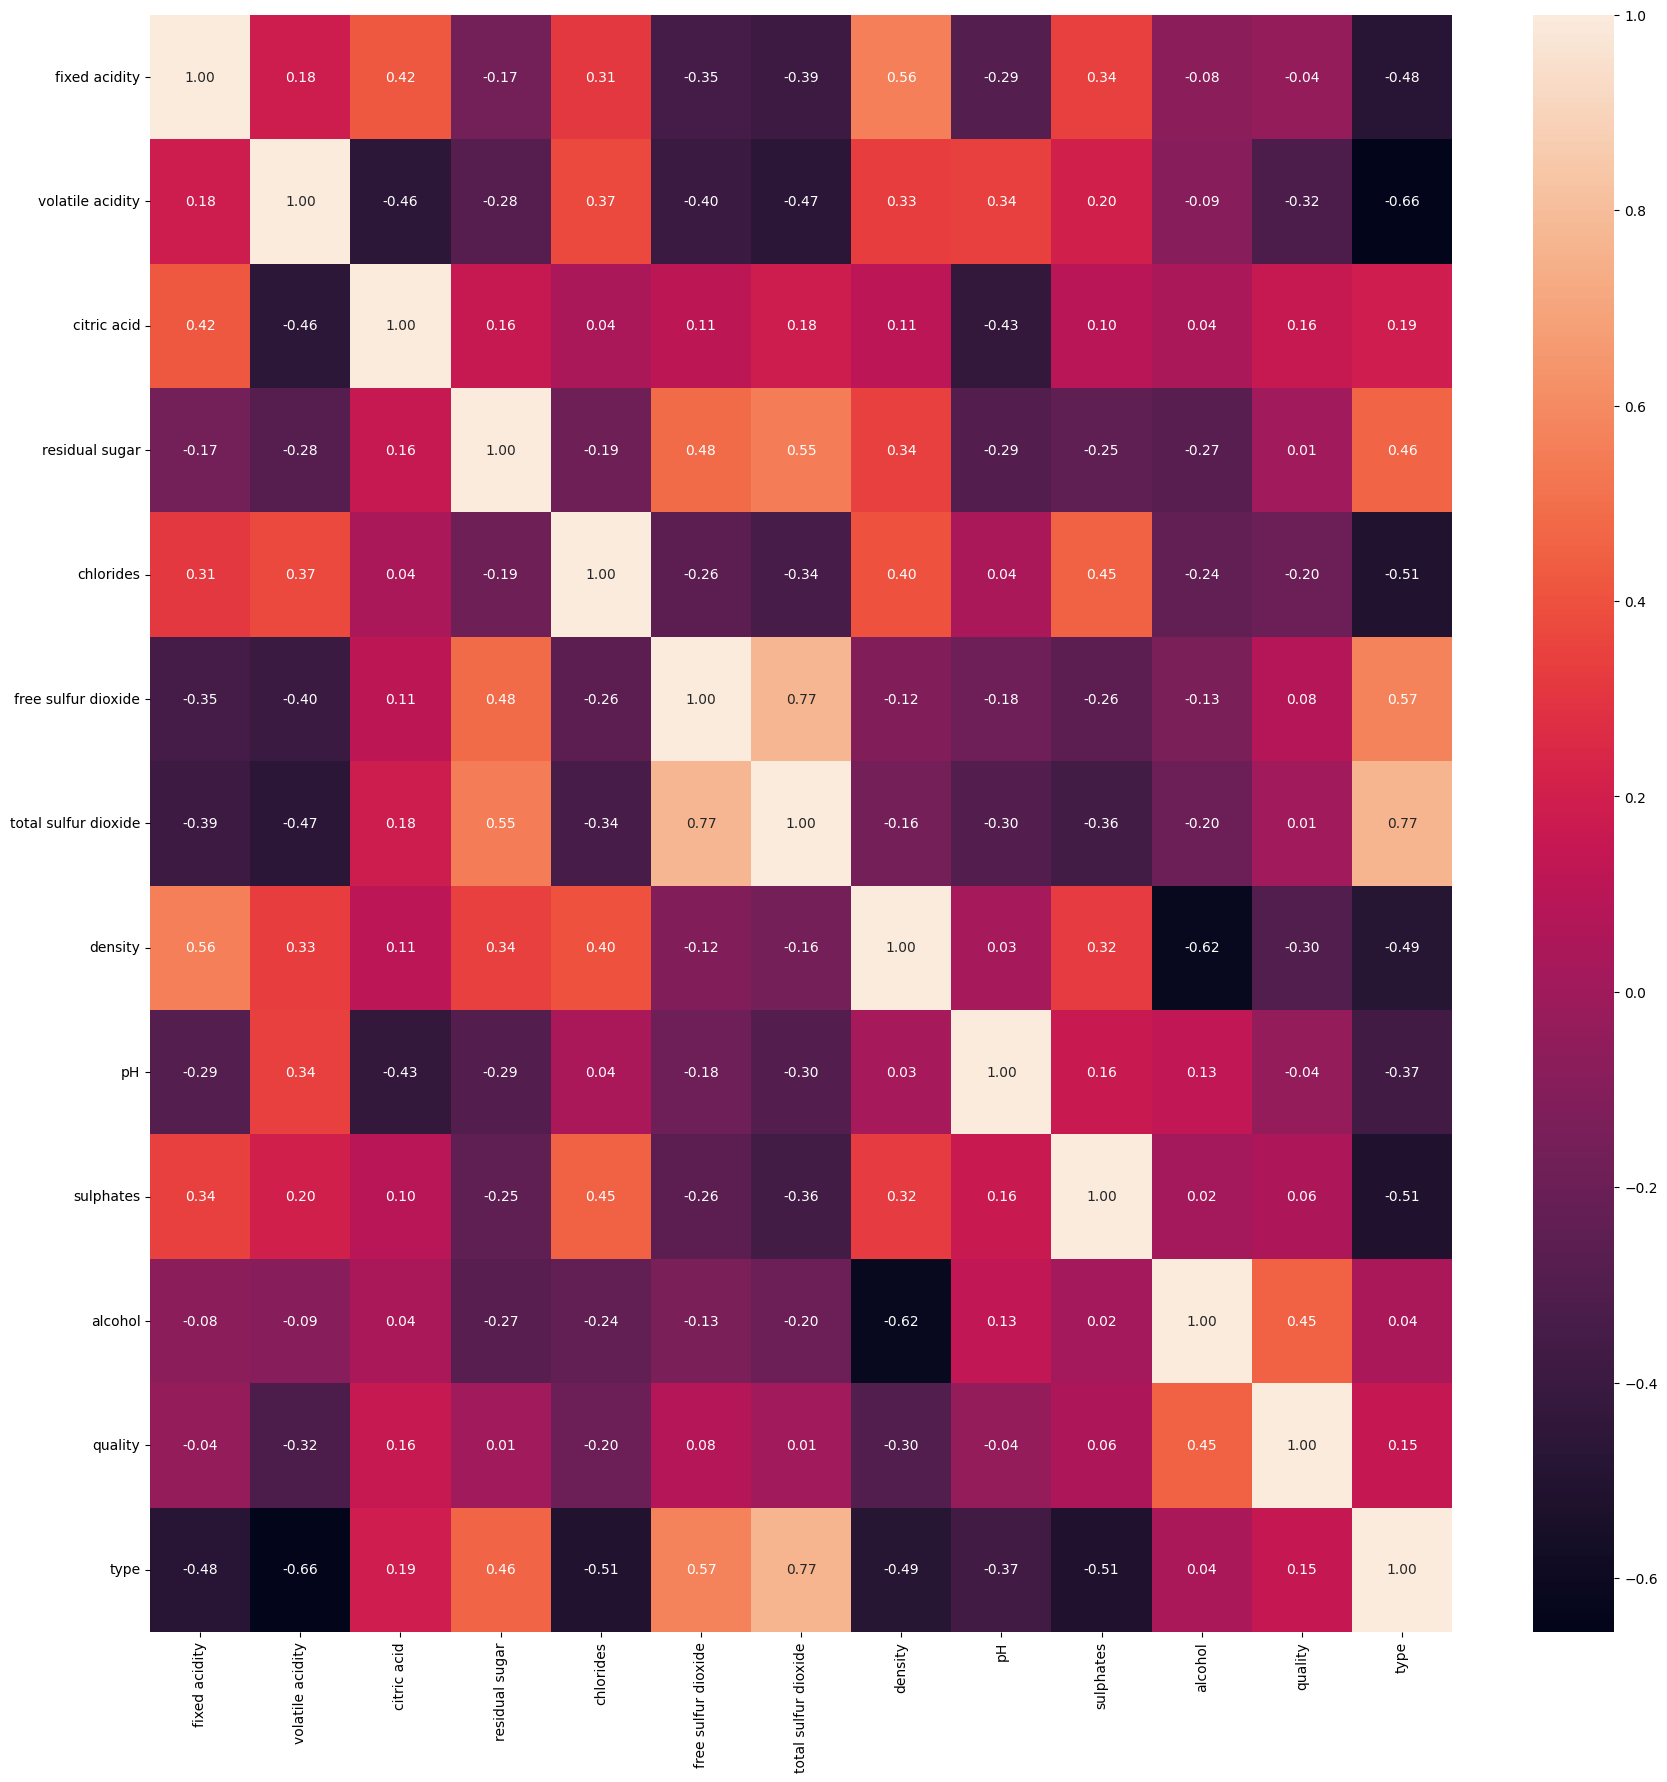

In [19]:
prueba = pd.concat([data_X_pro2, data_transformed], axis=1)

plt.figure(figsize= (21,21))
sns.heatmap(data=prueba.corr(numeric_only= True), annot= True, fmt= '0.2f')
plt.show()

## Prueba con modelo base para seleccionar estandarizacion o normalizacion

In [20]:
from sklearn.model_selection import train_test_split
X_trainN, X_testN, y_trainN, y_testN = train_test_split(data_X_pro1, data_y, train_size=0.7, random_state=32)
X_trainE, X_testE, y_trainE, y_testE = train_test_split(data_X_pro2, data_y, train_size=0.7, random_state=32)
print(f'El tamaño del conjunto de entrenamiento normalizado es: {X_trainN.shape} {y_trainN.shape}\ny el tamaño del conjunto de validacion normalizado es {X_testN.shape, y_testN.shape}')
print(f'El tamaño del conjunto de entrenamiento estandarizado es: {X_trainE.shape} {y_trainE.shape}\ny el tamaño del conjunto de validacion estandarizado es {X_testE.shape, y_testE.shape}')

El tamaño del conjunto de entrenamiento normalizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion normalizado es ((2907, 12), (2907, 1))
El tamaño del conjunto de entrenamiento estandarizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion estandarizado es ((2907, 12), (2907, 1))


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
modelN1 = DecisionTreeClassifier(random_state=32)
modelN2 = KNeighborsClassifier()
modelE1 = DecisionTreeClassifier(random_state=32)
modelE2 = KNeighborsClassifier()
modelN1.fit(X_trainN, y_trainN)
modelN2.fit(X_trainN, y_trainN)
modelE1.fit(X_trainE, y_trainE)
modelE2.fit(X_trainE, y_trainE)
pred1N = modelN1.predict(X_testN)
pred2N = modelN2.predict(X_testN)
pred1E = modelE1.predict(X_testE)
pred2E = modelE2.predict(X_testE)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_testN, pred1N))
print(classification_report(y_testE, pred1E))

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [23]:
print(classification_report(y_testN, pred2N))
print(classification_report(y_testE, pred2E))

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [24]:
print("Train scores:")
print(f"DecisionTree Norm: {modelN1.score(X_trainN, y_trainN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_trainE, y_trainE):.4f}")

print("\nTest scores:")
print(f"DecisionTree Norm: {modelN1.score(X_testN, y_testN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_testE, y_testE):.4f}")

Train scores:
DecisionTree Norm: 0.9997
DecisionTree Est:  0.9997

Test scores:
DecisionTree Norm: 0.9911
DecisionTree Est:  0.9914


Se decidió usar el MinMaxScaler() LOS QUE TIENEN N

## Ajuste de Hiperparametros para los 10 modelos a probar
- Naive Bayes
- Regresión Logística
- K vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting 
- Red Neuronal Artificial

In [27]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [29]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
model_1 = GaussianNB()
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf1 = GridSearchCV(estimator=model_1,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf1.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-09])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more message

In [30]:
cv_results = pd.DataFrame(clf1.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_var_smoothing,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
13,0.012517,0.003815,0.069764,0.013733,0.065793,{'var_smoothing': 0.0657933224657568},0.971260,0.974926,0.978614,0.972714,...,0.003420,1,0.971246,0.974920,0.978601,0.972705,0.968285,0.973151,0.003474,1
12,0.013217,0.003351,0.069140,0.019467,0.081113,{'var_smoothing': 0.08111308307896872},0.970523,0.975664,0.978614,0.972714,...,0.003810,2,0.970510,0.975657,0.978601,0.972705,0.967547,0.973004,0.003859,2
19,0.013981,0.003882,0.071187,0.012820,0.018738,{'var_smoothing': 0.01873817422860384},0.973471,0.974926,0.975664,0.969027,...,0.002532,3,0.973463,0.974923,0.975651,0.969017,0.970498,0.972710,0.002555,3
18,0.011306,0.002771,0.105107,0.029766,0.023101,{'var_smoothing': 0.02310129700083159},0.973471,0.974926,0.977139,0.970501,...,0.003325,4,0.973463,0.974923,0.977125,0.970492,0.967546,0.972710,0.003363,4
17,0.010778,0.003100,0.071055,0.035266,0.028480,{'var_smoothing': 0.02848035868435802},0.973471,0.974926,0.976401,0.971976,...,0.003254,5,0.973463,0.974923,0.976386,0.971966,0.966809,0.972709,0.003297,5
14,0.014479,0.006899,0.067998,0.019139,0.053367,{'var_smoothing': 0.0533669923120631},0.973471,0.975664,0.977139,0.971239,...,0.003814,6,0.973462,0.975658,0.977123,0.971229,0.966072,0.972709,0.003873,6
15,0.011150,0.003432,0.054737,0.015503,0.043288,{'var_smoothing': 0.04328761281083057},0.973471,0.974189,0.977139,0.971239,...,0.003380,7,0.973462,0.974184,0.977123,0.971229,0.966809,0.972561,0.003439,7
11,0.035798,0.049092,0.060304,0.011470,0.100000,{'var_smoothing': 0.1},0.969786,0.976401,0.978614,0.971976,...,0.004467,8,0.969773,0.976394,0.978601,0.971968,0.966069,0.972561,0.004504,8
16,0.012529,0.003485,0.060602,0.018977,0.035112,{'var_smoothing': 0.03511191734215131},0.972734,0.974189,0.976401,0.971239,...,0.003167,9,0.972725,0.974185,0.976386,0.971229,0.966809,0.972267,0.003216,9
10,0.016875,0.009400,0.066759,0.020454,0.123285,{'var_smoothing': 0.12328467394420659},0.969786,0.977139,0.977139,0.970501,...,0.004129,10,0.969773,0.977131,0.977125,0.970491,0.966806,0.972265,0.004158,10


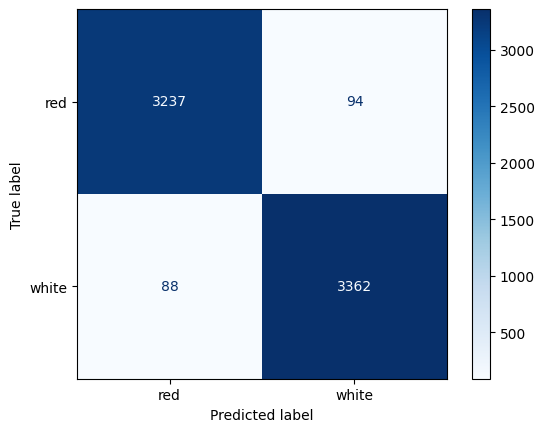

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict
labels = data['type'].unique()

best_clf1 = clf1.best_estimator_
y_train_pred = cross_val_predict(best_clf1, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val = confusion_matrix(y_trainN, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Blues)

In [41]:
#Regresión Logística
from sklearn.linear_model import LogisticRegression
model_2 = LogisticRegression(solver= 'saga', random_state=32)
param_grid = {
    'penalty':['l1','l2','elasticnet'],
    'C':[0.001, 0.01, 0.1,1,10,100,1000]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf2 = GridSearchCV(estimator=model_2,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf2.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: th

In [42]:
cv_results2 = pd.DataFrame(clf2.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results2.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
9,0.204159,0.022872,0.057669,0.004928,1.0,l1,"{'C': 1, 'penalty': 'l1'}",0.991894,0.992625,0.986726,...,0.002971,1,0.991889,0.992623,0.986720,0.989670,0.995573,0.991295,0.002966,1
12,0.203079,0.030145,0.055218,0.012669,10.0,l1,"{'C': 10, 'penalty': 'l1'}",0.991894,0.993363,0.985988,...,0.003096,2,0.991889,0.993361,0.985983,0.989670,0.994835,0.991148,0.003095,2
17,0.154476,0.022503,0.052814,0.009560,100.0,elasticnet,"{'C': 100, 'penalty': 'elasticnet'}",0.991894,0.993363,0.985988,...,0.003179,3,0.991889,0.993361,0.985983,0.988932,0.994835,0.991000,0.003179,3
16,0.155421,0.007460,0.048380,0.001010,100.0,l2,"{'C': 100, 'penalty': 'l2'}",0.991894,0.993363,0.985988,...,0.003179,3,0.991889,0.993361,0.985983,0.988932,0.994835,0.991000,0.003179,3
15,0.192050,0.009849,0.054504,0.010943,100.0,l1,"{'C': 100, 'penalty': 'l1'}",0.991894,0.992625,0.985988,...,0.003002,3,0.991889,0.992623,0.985983,0.989670,0.994835,0.991000,0.003003,5
20,0.138621,0.004689,0.035647,0.003353,1000.0,elasticnet,"{'C': 1000, 'penalty': 'elasticnet'}",0.991894,0.992625,0.985988,...,0.003002,3,0.991889,0.992623,0.985983,0.989670,0.994835,0.991000,0.003003,5
18,0.205549,0.017836,0.049499,0.005310,1000.0,l1,"{'C': 1000, 'penalty': 'l1'}",0.991894,0.992625,0.985988,...,0.003002,3,0.991889,0.992623,0.985983,0.989670,0.994835,0.991000,0.003003,5
19,0.144451,0.014827,0.046613,0.008001,1000.0,l2,"{'C': 1000, 'penalty': 'l2'}",0.991894,0.992625,0.985988,...,0.003002,3,0.991889,0.992623,0.985983,0.989670,0.994835,0.991000,0.003003,5
13,0.129131,0.020521,0.053782,0.008625,10.0,l2,"{'C': 10, 'penalty': 'l2'}",0.991894,0.993363,0.985988,...,0.003015,9,0.991889,0.993361,0.985983,0.988933,0.994098,0.990853,0.003010,9
14,0.115505,0.006513,0.047078,0.004204,10.0,elasticnet,"{'C': 10, 'penalty': 'elasticnet'}",0.991894,0.993363,0.985988,...,0.003015,9,0.991889,0.993361,0.985983,0.988933,0.994098,0.990853,0.003010,9


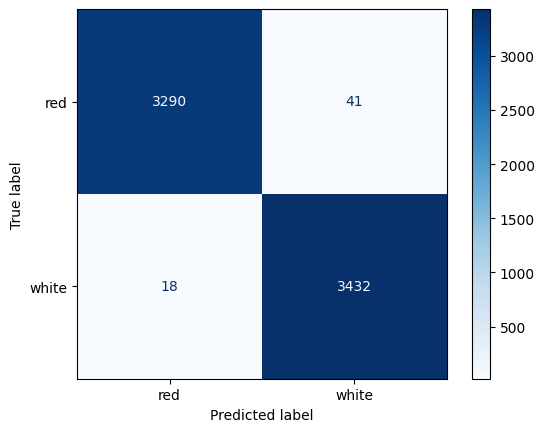

In [43]:
best_clf2 = clf2.best_estimator_
y_train_pred2 = cross_val_predict(best_clf2, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val2 = confusion_matrix(y_trainN, y_train_pred2)
ConfusionMatrixDisplay(confusion_matrix=cm_val2, display_labels=labels).plot(cmap=plt.cm.Blues)

In [44]:
#k vecinos mas cercanos
from sklearn.neighbors import KNeighborsClassifier
model_3 = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3,5,7,9,11,15,101],
    'p':[1,2]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf3 = GridSearchCV(estimator=model_3,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf3.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [45]:
cv_results3 = pd.DataFrame(clf3.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results3.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
0,0.040280,0.004957,0.206506,0.027886,3,1,"{'n_neighbors': 3, 'p': 1}",0.995578,0.997050,0.994838,...,0.001918,1,0.995578,0.997050,0.994836,0.991150,0.994099,0.994543,0.001957,1
1,0.046487,0.004032,0.191090,0.026398,3,2,"{'n_neighbors': 3, 'p': 2}",0.992631,0.996313,0.991150,...,0.002845,2,0.992630,0.996312,0.991149,0.988200,0.988938,0.991446,0.002898,2
2,0.050406,0.002100,0.238505,0.041844,5,1,"{'n_neighbors': 5, 'p': 1}",0.991157,0.994100,0.991150,...,0.001762,3,0.991154,0.994099,0.991148,0.988936,0.989674,0.991002,0.001770,3
4,0.023670,0.002211,0.209425,0.026235,7,1,"{'n_neighbors': 7, 'p': 1}",0.991157,0.993363,0.988938,...,0.002355,4,0.991154,0.993362,0.988935,0.986722,0.991886,0.990412,0.002333,4
6,0.023963,0.002557,0.224169,0.038501,9,1,"{'n_neighbors': 9, 'p': 1}",0.990420,0.992625,0.988201,...,0.001563,5,0.990418,0.992624,0.988196,0.988934,0.990410,0.990116,0.001520,5
8,0.025855,0.003452,0.229926,0.015793,11,1,"{'n_neighbors': 11, 'p': 1}",0.988209,0.990413,0.988201,...,0.000887,6,0.988206,0.990411,0.988196,0.988935,0.989672,0.989084,0.000859,6
3,0.035644,0.005952,0.170745,0.020214,5,2,"{'n_neighbors': 5, 'p': 2}",0.989683,0.993363,0.987463,...,0.002502,7,0.989681,0.993362,0.987461,0.986724,0.986725,0.988790,0.002530,7
5,0.025349,0.004355,0.187267,0.030863,7,2,"{'n_neighbors': 7, 'p': 2}",0.988946,0.994100,0.988201,...,0.003119,8,0.988943,0.994099,0.988197,0.984510,0.987461,0.988642,0.003116,8
10,0.029946,0.004857,0.262056,0.022372,15,1,"{'n_neighbors': 15, 'p': 1}",0.988946,0.989676,0.988201,...,0.001282,9,0.988943,0.989674,0.988196,0.985985,0.987460,0.988052,0.001270,9
7,0.030928,0.004420,0.250810,0.044391,9,2,"{'n_neighbors': 9, 'p': 2}",0.988209,0.991150,0.985251,...,0.002119,10,0.988206,0.991149,0.985247,0.986722,0.985985,0.987462,0.002087,10


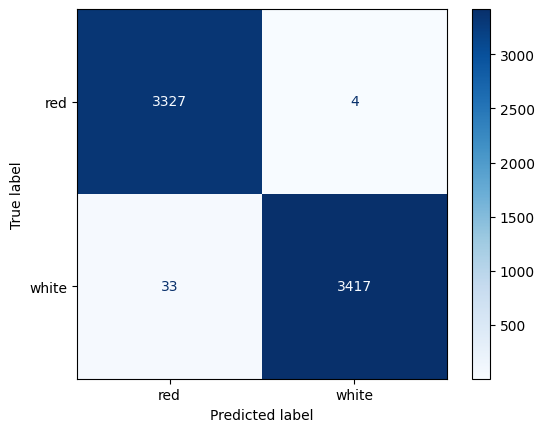

In [46]:
best_clf3 = clf3.best_estimator_
y_train_pred3 = cross_val_predict(best_clf3, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val3 = confusion_matrix(y_trainN, y_train_pred3)
ConfusionMatrixDisplay(confusion_matrix=cm_val3, display_labels=labels).plot(cmap=plt.cm.Blues)

In [47]:
#Maquina de soporte vectorial
from sklearn.svm import SVC
model_4 = SVC(random_state=32)
param_grid = {
    'C': [0.001, 0.01, 0.1, 10, 100],
    'kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
    'degree': [2,3]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf4 = GridSearchCV(estimator=model_4,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf4.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'degree': [2, 3], 'kernel': ['poly', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the 

In [48]:
cv_results4 = pd.DataFrame(clf4.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results4.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_degree,param_kernel,params,split0_test_accuracy,split1_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
38,0.179877,0.065141,0.131156,0.083135,100.0,3,rbf,"{'C': 100, 'degree': 3, 'kernel': 'rbf'}",0.999263,0.996313,...,0.001484,1,0.999263,0.996312,0.996311,0.994837,0.995574,0.996459,0.001505,1
34,0.184562,0.068727,0.169062,0.115644,100.0,2,rbf,"{'C': 100, 'degree': 2, 'kernel': 'rbf'}",0.999263,0.996313,...,0.001484,1,0.999263,0.996312,0.996311,0.994837,0.995574,0.996459,0.001505,1
28,0.403489,0.078801,0.127227,0.069375,10.0,3,poly,"{'C': 10, 'degree': 3, 'kernel': 'poly'}",0.997052,0.995575,...,0.001441,3,0.997051,0.995574,0.993359,0.993361,0.995574,0.994984,0.001431,3
36,0.780236,0.222049,0.070112,0.013273,100.0,3,poly,"{'C': 100, 'degree': 3, 'kernel': 'poly'}",0.996315,0.994838,...,0.001156,4,0.996315,0.994837,0.994836,0.992625,0.994837,0.994690,0.001181,4
30,0.121653,0.027279,0.099104,0.025574,10.0,3,rbf,"{'C': 10, 'degree': 3, 'kernel': 'rbf'}",0.997789,0.993363,...,0.002144,5,0.997788,0.993361,0.992621,0.992622,0.996312,0.994541,0.002119,5
26,0.155298,0.043679,0.152214,0.077476,10.0,2,rbf,"{'C': 10, 'degree': 2, 'kernel': 'rbf'}",0.997789,0.993363,...,0.002144,5,0.997788,0.993361,0.992621,0.992622,0.996312,0.994541,0.002119,5
32,0.862744,0.253363,0.102669,0.047313,100.0,2,poly,"{'C': 100, 'degree': 2, 'kernel': 'poly'}",0.996315,0.991888,...,0.002429,7,0.996314,0.991886,0.991145,0.991148,0.996311,0.993361,0.002425,7
24,0.352738,0.090108,0.111198,0.022518,10.0,2,poly,"{'C': 10, 'degree': 2, 'kernel': 'poly'}",0.994842,0.993363,...,0.002039,8,0.994839,0.993361,0.991146,0.990409,0.995574,0.993066,0.002014,8
20,0.185773,0.047564,0.117245,0.039247,0.1,3,poly,"{'C': 0.1, 'degree': 3, 'kernel': 'poly'}",0.992631,0.993363,...,0.002512,9,0.992626,0.993361,0.989670,0.989670,0.996311,0.992328,0.002496,9
16,0.246593,0.053431,0.162831,0.062694,0.1,2,poly,"{'C': 0.1, 'degree': 2, 'kernel': 'poly'}",0.991894,0.994100,...,0.002850,10,0.991889,0.994098,0.987457,0.990408,0.995573,0.991885,0.002839,10


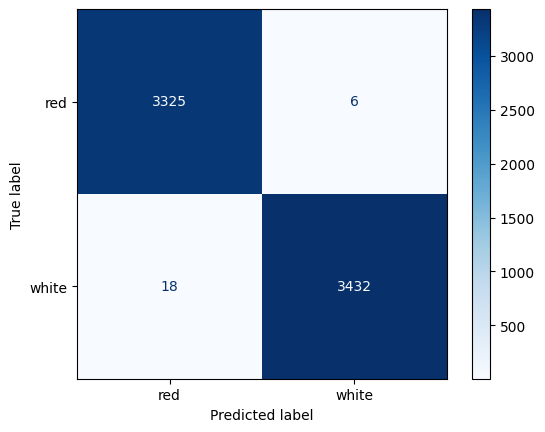

In [49]:
best_clf4 = clf4.best_estimator_
y_train_pred4 = cross_val_predict(best_clf4, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val4 = confusion_matrix(y_trainN, y_train_pred4)
ConfusionMatrixDisplay(confusion_matrix=cm_val4, display_labels=labels).plot(cmap=plt.cm.Blues)

Profundidad del árbol: 14
Número de hojas: 66


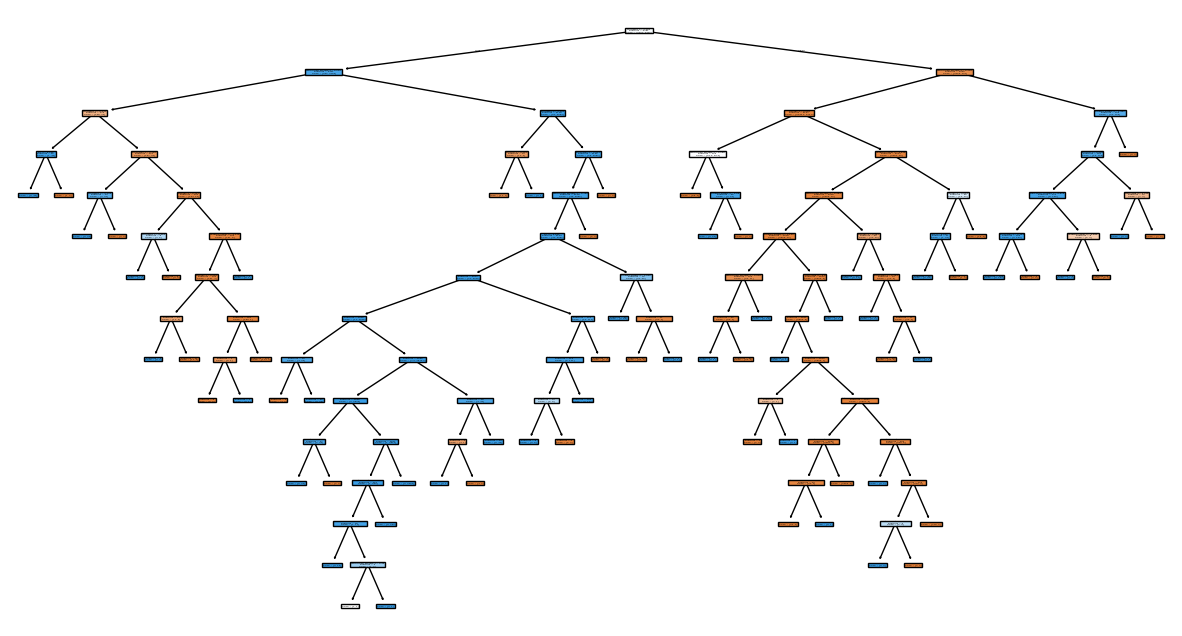

In [51]:
#Árbol de decisión
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state=32)
model_tree.fit(X_trainN, y_trainN)
print(f'Profundidad del árbol: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(15,8))
plot = plot_tree(decision_tree= model_tree, feature_names=num_cols, filled=True, impurity=False, ax=ax)

In [53]:
#Árbol de decisión
model_5 = DecisionTreeClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None, 5,10,20,30,50,60],
    'min_samples_split': [2,4,6]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf5 = GridSearchCV(estimator=model_5,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf5.fit(X_trainN, y_trainN)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",S

In [ ]:
cv_results5 = pd.DataFrame(clf5.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results5.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,params,split0_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
85,0.028900,0.004119,0.050292,0.018412,entropy,14,None,4,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.992631,...,0.001159,1,0.992630,0.991149,0.994836,0.992624,0.993361,0.992920,0.001198,1
295,0.086587,0.031960,0.137992,0.031126,log_loss,14,None,4,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.992631,...,0.001159,1,0.992630,0.991149,0.994836,0.992624,0.993361,0.992920,0.001198,1
294,0.085753,0.030696,0.120400,0.020863,log_loss,14,None,2,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994842,...,0.001259,1,0.994840,0.991887,0.994098,0.991887,0.991886,0.992920,0.001287,3
84,0.030408,0.007510,0.048193,0.019206,entropy,14,None,2,"{'criterion': 'entropy', 'max_depth': 14, 'max...",0.994842,...,0.001259,1,0.994840,0.991887,0.994098,0.991887,0.991886,0.992920,0.001287,3
274,0.031883,0.004292,0.050899,0.009546,log_loss,10,None,4,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",0.990420,...,0.001424,5,0.990418,0.993362,0.994836,0.992624,0.992623,0.992773,0.001428,5
64,0.044422,0.036386,0.096470,0.040990,entropy,10,None,4,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.990420,...,0.001424,5,0.990418,0.993362,0.994836,0.992624,0.992623,0.992773,0.001428,5
63,0.025367,0.001900,0.047902,0.008507,entropy,10,None,2,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.990420,...,0.001354,7,0.990418,0.994099,0.994098,0.992624,0.992623,0.992772,0.001350,7
273,0.028501,0.004625,0.050883,0.006331,log_loss,10,None,2,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",0.990420,...,0.001354,7,0.990418,0.994099,0.994098,0.992624,0.992623,0.992772,0.001350,7
312,0.067796,0.026757,0.102807,0.019366,log_loss,14,60,2,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994842,...,0.002285,9,0.994840,0.988200,0.993361,0.992624,0.994099,0.992625,0.002333,9
309,0.054613,0.010513,0.119154,0.049661,log_loss,14,50,2,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",0.994842,...,0.002285,9,0.994840,0.988200,0.993361,0.992624,0.994099,0.992625,0.002333,9


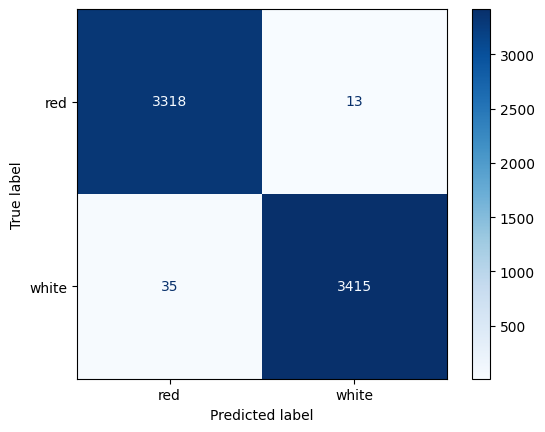

In [55]:
best_clf5 = clf5.best_estimator_
y_train_pred5 = cross_val_predict(best_clf5, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val5 = confusion_matrix(y_trainN, y_train_pred5)
ConfusionMatrixDisplay(confusion_matrix=cm_val5, display_labels=labels).plot(cmap=plt.cm.Blues)

In [59]:
#Extra Tree Classifier
from sklearn.ensemble import ExtraTreesClassifier
model_6 = ExtraTreesClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf6 = GridSearchCV(estimator=model_6,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf6.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [ ]:
cv_results6 = pd.DataFrame(clf6.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results6.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
761,1.512405,0.127162,0.150462,0.037246,gini,14,None,4,200,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.000994,1,1.0,0.998525,0.997787,0.997787,1.0,0.998820,0.001001,1
1182,5.039935,0.784565,0.624283,0.303319,log_loss,14,None,4,400,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001440,2,1.0,0.999262,0.996311,0.997787,1.0,0.998672,0.001431,2
1181,1.296765,0.264407,0.419474,0.248172,log_loss,14,None,4,200,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001440,2,1.0,0.999262,0.996311,0.997787,1.0,0.998672,0.001431,2
1183,7.414319,0.640949,0.906962,0.366093,log_loss,14,None,4,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001440,2,1.0,0.999262,0.996311,0.997787,1.0,0.998672,0.001431,2
342,3.054776,0.442693,0.340075,0.043159,entropy,14,None,4,400,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001440,2,1.0,0.999262,0.996311,0.997787,1.0,0.998672,0.001431,2
341,1.399298,0.160597,0.226900,0.051041,entropy,14,None,4,200,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001440,2,1.0,0.999262,0.996311,0.997787,1.0,0.998672,0.001431,2
343,3.806462,0.611959,0.362520,0.068825,entropy,14,None,4,500,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001440,2,1.0,0.999262,0.996311,0.997787,1.0,0.998672,0.001431,2
340,0.798958,0.179073,0.183742,0.054026,entropy,14,None,4,100,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.001663,8,1.0,0.999262,0.995573,0.998525,1.0,0.998672,0.001643,8
1180,0.606569,0.058594,0.099616,0.007972,log_loss,14,None,4,100,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001663,8,1.0,0.999262,0.995573,0.998525,1.0,0.998672,0.001643,8
762,3.172248,0.322922,0.426410,0.061823,gini,14,None,4,400,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.001408,10,1.0,0.998525,0.996311,0.997787,1.0,0.998525,0.001400,10


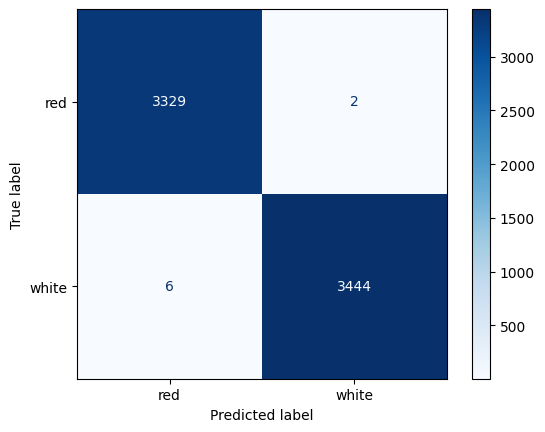

In [61]:
best_clf6 = clf6.best_estimator_
y_train_pred6 = cross_val_predict(best_clf6, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val6 = confusion_matrix(y_trainN, y_train_pred6)
ConfusionMatrixDisplay(confusion_matrix=cm_val6, display_labels=labels).plot(cmap=plt.cm.Blues)

In [65]:
#Random forest Classifier
from sklearn.ensemble import RandomForestClassifier
model_7 = RandomForestClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf7 = GridSearchCV(estimator=model_7,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf7.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [66]:
cv_results7 = pd.DataFrame(clf7.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results7.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
255,8.026611,1.041035,0.387209,0.140142,entropy,10,None,2,500,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001290,1,0.999263,0.998525,0.996311,0.997787,1.000000,0.998377,0.001269,1
1094,6.410707,1.080549,0.236479,0.040664,log_loss,10,None,2,400,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001290,1,0.999263,0.998525,0.996311,0.997787,1.000000,0.998377,0.001269,1
1095,7.876461,0.891128,0.428667,0.106738,log_loss,10,None,2,500,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001290,1,0.999263,0.998525,0.996311,0.997787,1.000000,0.998377,0.001269,1
254,6.749328,1.893617,0.270728,0.020025,entropy,10,None,2,400,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001290,1,0.999263,0.998525,0.996311,0.997787,1.000000,0.998377,0.001269,1
259,7.597714,0.780845,0.297727,0.056459,entropy,10,None,4,500,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001303,5,0.999263,0.997787,0.996311,0.997787,1.000000,0.998230,0.001286,5
1099,6.976682,0.734842,0.352348,0.146218,log_loss,10,None,4,500,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001303,5,0.999263,0.997787,0.996311,0.997787,1.000000,0.998230,0.001286,5
1098,6.150299,1.609359,0.214365,0.038313,log_loss,10,None,4,400,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.001303,5,0.999263,0.997787,0.996311,0.997787,1.000000,0.998230,0.001286,5
258,6.659754,1.182735,0.264439,0.027591,entropy,10,None,4,400,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.001303,5,0.999263,0.997787,0.996311,0.997787,1.000000,0.998230,0.001286,5
1179,6.711714,0.257125,0.298487,0.025459,log_loss,14,None,2,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001130,5,0.999263,0.998525,0.996311,0.997787,0.999262,0.998230,0.001104,9
1176,1.356379,0.124620,0.140559,0.016571,log_loss,14,None,2,100,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.001130,5,0.999263,0.998525,0.996311,0.997787,0.999262,0.998230,0.001104,9


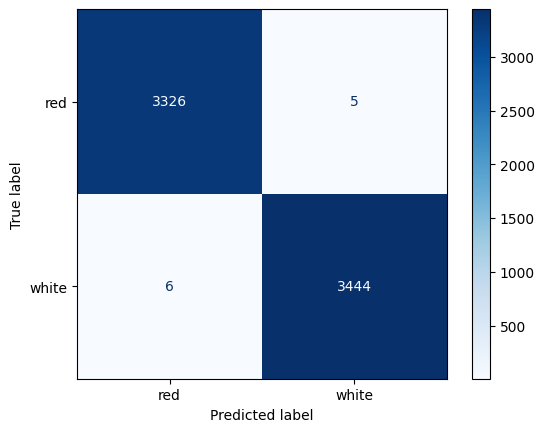

In [67]:
best_clf7 = clf7.best_estimator_
y_train_pred7 = cross_val_predict(best_clf7, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val7 = confusion_matrix(y_trainN, y_train_pred7)
ConfusionMatrixDisplay(confusion_matrix=cm_val7, display_labels=labels).plot(cmap=plt.cm.Blues)

In [68]:
#Adaptive boosting Classifier
from sklearn.ensemble import AdaBoostClassifier
model_8 = AdaBoostClassifier(random_state=32)
param_grid = {
    'learning_rate': [0.01, 0.1, 1,10,100],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf8 = GridSearchCV(estimator=model_8,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf8.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the 

In [69]:
cv_results8 = pd.DataFrame(clf8.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results8.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_n_estimators,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
11,18.838303,0.725405,0.684014,0.310083,1.00,500,"{'learning_rate': 1, 'n_estimators': 500}",0.997052,0.995575,0.992625,...,0.002178,1,0.997052,0.995574,0.992624,0.998525,0.998525,0.996460,0.002208,1
10,13.821826,0.757379,0.957935,0.391630,1.00,400,"{'learning_rate': 1, 'n_estimators': 400}",0.997052,0.994838,0.993363,...,0.001898,2,0.997052,0.994837,0.993362,0.997787,0.998525,0.996312,0.001923,2
9,3.575563,0.213702,0.184705,0.039999,1.00,200,"{'learning_rate': 1, 'n_estimators': 200}",0.994105,0.994838,0.991888,...,0.002437,3,0.994103,0.994837,0.991886,0.996312,0.999262,0.995280,0.002450,3
8,1.720871,0.166297,0.166204,0.048333,1.00,100,"{'learning_rate': 1, 'n_estimators': 100}",0.993368,0.992625,0.986726,...,0.003297,4,0.993366,0.992624,0.986722,0.992623,0.997049,0.992477,0.003312,4
7,13.198862,1.044672,0.951211,0.370653,0.10,500,"{'learning_rate': 0.1, 'n_estimators': 500}",0.985262,0.988201,0.983776,...,0.002412,5,0.985257,0.988197,0.983768,0.985243,0.990409,0.986575,0.002397,5
6,6.551919,0.424887,0.233745,0.035131,0.10,400,"{'learning_rate': 0.1, 'n_estimators': 400}",0.985999,0.987463,0.983038,...,0.002244,6,0.985993,0.987460,0.983029,0.985243,0.989671,0.986279,0.002219,6
5,2.590910,0.209778,0.159208,0.025682,0.10,200,"{'learning_rate': 0.1, 'n_estimators': 200}",0.984525,0.988201,0.977876,...,0.004266,7,0.984519,0.988197,0.977867,0.980814,0.988934,0.984066,0.004242,7
4,1.256752,0.061169,0.084974,0.010053,0.10,100,"{'learning_rate': 0.1, 'n_estimators': 100}",0.982314,0.986726,0.972714,...,0.005617,8,0.982309,0.986722,0.972706,0.976391,0.986722,0.980970,0.005607,8
3,7.185897,0.527888,0.407010,0.068883,0.01,500,"{'learning_rate': 0.01, 'n_estimators': 500}",0.980103,0.979351,0.971239,...,0.004165,9,0.980095,0.979346,0.971232,0.971966,0.980817,0.976691,0.004190,9
2,5.277271,0.291314,0.251382,0.030736,0.01,400,"{'learning_rate': 0.01, 'n_estimators': 400}",0.979366,0.979351,0.971976,...,0.004056,10,0.979358,0.979347,0.971970,0.971229,0.980817,0.976544,0.004079,10


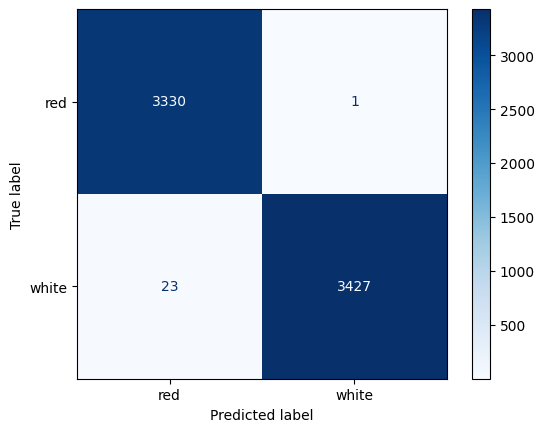

In [70]:
best_clf8 = clf8.best_estimator_
y_train_pred8 = cross_val_predict(best_clf8, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val8 = confusion_matrix(y_trainN, y_train_pred8)
ConfusionMatrixDisplay(confusion_matrix=cm_val8, display_labels=labels).plot(cmap=plt.cm.Blues)

In [73]:
#GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model_9 = GradientBoostingClassifier(random_state=32)
param_grid = {
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [5,7,9,12],
    'max_leaf_nodes': [10,40,None],
    'min_samples_split': [2,3],
    'n_estimators': [100,200,300,400]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf9 = RandomizedSearchCV(estimator= model_9, param_distributions=param_grid, cv=cv, scoring=scoring,
                          refit='f1_macro',
                          n_jobs=-1, n_iter=96)
clf9.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=32)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': [5, 7, ...], 'max_leaf_nodes': [10, 40, ...], 'min_samples_split': [2, 3], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",96
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the 

In [74]:
cv_results9 = pd.DataFrame(clf9.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results9.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_leaf_nodes,param_max_depth,param_criterion,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
93,14.459678,0.899886,0.089447,0.017177,300,2,None,5,squared_error,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.000875,1,0.999263,0.997050,0.997787,0.997787,0.999262,0.998230,0.000885,1
53,13.004109,1.739038,0.099389,0.008996,300,3,40,5,squared_error,"{'n_estimators': 300, 'min_samples_split': 3, ...",...,0.000542,2,0.998526,0.997050,0.997787,0.997787,0.998525,0.997935,0.000552,2
92,17.274724,1.424465,0.066196,0.019626,400,3,None,5,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.001196,3,0.999263,0.997050,0.996311,0.997787,0.999262,0.997935,0.001181,3
4,16.799918,1.870813,0.225626,0.158941,300,2,40,5,friedman_mse,"{'n_estimators': 300, 'min_samples_split': 2, ...",...,0.001025,4,0.998526,0.996312,0.997787,0.997050,0.999262,0.997787,0.001043,4
26,15.159071,3.165967,0.139925,0.027201,300,3,None,5,squared_error,"{'n_estimators': 300, 'min_samples_split': 3, ...",...,0.000643,5,0.998526,0.997050,0.997787,0.997050,0.998525,0.997787,0.000660,5
89,14.902855,0.884300,0.117600,0.014097,400,3,None,5,squared_error,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.001062,6,0.998526,0.997050,0.996311,0.997787,0.999262,0.997787,0.001044,6
52,8.258991,1.291349,0.091533,0.020655,200,2,None,5,squared_error,"{'n_estimators': 200, 'min_samples_split': 2, ...",...,0.001040,6,0.999263,0.997787,0.997049,0.996312,0.998525,0.997787,0.001043,7
82,15.640351,0.411554,0.148454,0.028111,400,3,10,7,squared_error,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.001220,8,0.997789,0.997050,0.995573,0.997787,0.999262,0.997492,0.001199,8
32,16.515026,1.645614,0.176134,0.034173,400,3,10,7,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.001220,8,0.997789,0.997050,0.995573,0.997787,0.999262,0.997492,0.001199,8
91,7.836041,0.700804,0.123255,0.016028,200,3,None,5,friedman_mse,"{'n_estimators': 200, 'min_samples_split': 3, ...",...,0.001002,8,0.998526,0.997787,0.996311,0.996312,0.998525,0.997492,0.001001,10


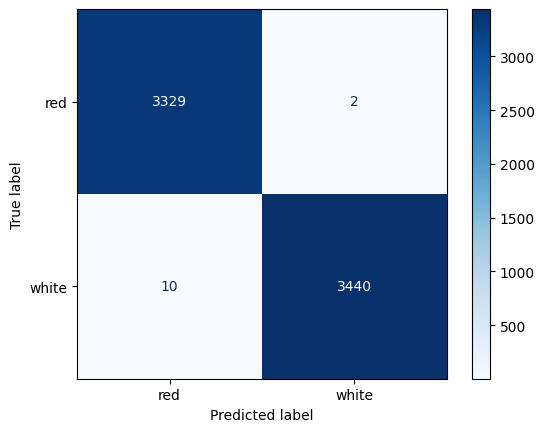

In [75]:
best_clf9 = clf9.best_estimator_
y_train_pred9 = cross_val_predict(best_clf9, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val9 = confusion_matrix(y_trainN, y_train_pred9)
ConfusionMatrixDisplay(confusion_matrix=cm_val9, display_labels=labels).plot(cmap=plt.cm.Blues)

In [76]:
#Red Neuronal Perceptrón Multicapa
from sklearn.neural_network import MLPClassifier
model_10 = MLPClassifier(random_state=32)
param_grid = {
    'hidden_layer_sizes': [(10,),(20,10,5),(20,10),(20,),(50,40,30,20,10)],
    'activation': ['relu','tanh','logistic'],
    'solver': ['adam','lbfgs','sgd'],
    'learning_rate_init': [0.01, 0.1, 1, 10, 100],
    'max_iter': [50,70,100,200]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf10 = RandomizedSearchCV(estimator= model_10, param_distributions=param_grid, cv=cv, scoring=scoring,
                           refit='f1_macro',
                          n_jobs=-1, n_iter=180)
clf10.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 900.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neura

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=32)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(10,), (20, ...), ...], 'learning_rate_init': [0.01, 0.1, ...], 'max_iter': [50, 70, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",180
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffl

In [77]:
cv_results10 = pd.DataFrame(clf10.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results10.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_hidden_layer_sizes,param_activation,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
140,25.710629,2.667747,0.130814,0.023446,lbfgs,200,10.00,"(50, 40, 30, 20, 10)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001804,1,0.997052,0.997049,0.997787,0.992624,0.995574,0.996017,0.001843,1
105,4.285666,0.897746,0.097816,0.041783,lbfgs,200,0.01,"(20, 10, 5)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.003689,2,0.997052,0.996312,0.987458,0.991147,0.995574,0.993509,0.003657,2
151,2.522317,0.604235,0.110881,0.026496,sgd,100,1.00,"(10,)",tanh,"{'solver': 'sgd', 'max_iter': 100, 'learning_r...",...,0.002055,4,0.993364,0.994836,0.991146,0.991147,0.996312,0.993361,0.002034,3
70,1.594617,0.336018,0.096162,0.033249,lbfgs,200,0.10,"(10,)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.002005,3,0.995576,0.994099,0.993360,0.989670,0.994098,0.993361,0.001981,4
121,2.286607,0.240882,0.117185,0.036275,adam,70,0.10,"(10,)",tanh,"{'solver': 'adam', 'max_iter': 70, 'learning_r...",...,0.002611,5,0.994102,0.994098,0.991147,0.989670,0.997049,0.993213,0.002574,5
135,2.028244,0.571838,0.115353,0.026448,lbfgs,200,1.00,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.003866,6,1.000000,0.990412,0.991884,0.988933,0.994099,0.993065,0.003864,6
137,5.837949,1.844240,0.123203,0.042336,lbfgs,200,10.00,"(20,)",logistic,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.002388,7,0.995577,0.994837,0.991886,0.988933,0.993361,0.992919,0.002362,7
177,3.820658,0.722370,0.053092,0.010673,lbfgs,200,0.10,"(20,)",logistic,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.002388,7,0.995577,0.994837,0.991886,0.988933,0.993361,0.992919,0.002362,7
74,14.926142,1.560109,0.129154,0.020294,lbfgs,200,100.00,"(50, 40, 30, 20, 10)",relu,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001293,9,0.992626,0.993361,0.991146,0.991885,0.994836,0.992771,0.001270,9
103,2.237463,0.378119,0.103640,0.035162,adam,70,0.01,"(20, 10)",relu,"{'solver': 'adam', 'max_iter': 70, 'learning_r...",...,0.001659,12,0.993364,0.994098,0.992621,0.989670,0.994098,0.992770,0.001644,10


## Validación cruzada en un mismo for

In [79]:
hola = [[],[]]
hola[0].append(4)
hola[1].append(6)
print(hola)
print(hola[0])

[[4], [6]]
[4]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score


strtfdKFold = StratifiedKFold(n_splits=10)
folds = list(strtfdKFold.split(X_trainN, y_trainN))

models = {
    'Naive Bayes': clf1.best_estimator_,
    'Regresión Logística': clf2.best_estimator_,
    'KNN': clf3.best_estimator_,
    'Maquina de Soporte Vectorial': clf4.best_estimator_,
    'Árbol de Decisión': clf5.best_estimator_,
    'Extra Trees': clf6.best_estimator_,
    'Random Forest': clf7.best_estimator_,
    'Adaptative Boosting': clf8.best_estimator_,
    'Gradient Boosting': clf9.best_estimator_,
    'Multi Layer Perceptron': clf10.best_estimator_
}

results = {name: {'accuracy': [], 'f1': [], 'recall': [], 'precision': [],
                  'y_test': [], 'y_pred': []}         
           for name in models}

for model_name, model in models.items():
    for train_index, test_index in folds:
        X_train_cv, X_test_cv = X_trainN[train_index], X_trainN[test_index]
        y_train_cv, y_test_cv = y_trainN[train_index], y_trainN[test_index]
        
        model.fit(X_train_cv, y_train_cv)
        pred = model.predict(X_test_cv)
        
        results[model_name]['y_test'].extend(y_test_cv) 
        results[model_name]['y_pred'].extend(pred)        
        results[model_name]['accuracy'].append(accuracy_score(y_test_cv, pred))
        results[model_name]['f1'].append(f1_score(y_test_cv, pred, average='macro'))
        results[model_name]['recall'].append(recall_score(y_test_cv, pred, average='macro'))
        results[model_name]['precision'].append(precision_score(y_test_cv, pred, average='macro'))